# Final Model Optimization

The previous notebooks demonstrated that both threshold selection and hyperparameter tuning can improve model performance.

The objective of this notebook is to evaluate the final optimized Random Forest model by combining:

- Hyperparameter Optimization
- Threshold Optimization

This represents the best-performing configuration identified during the project.

Dataset shape: (283726, 31)
Threshold: 0.3
Precision: 0.9125
Recall: 0.7684
F1: 0.8343
ROC-AUC: 0.9338
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.91      0.77      0.83        95

    accuracy                           1.00     56746
   macro avg       0.96      0.88      0.92     56746
weighted avg       1.00      1.00      1.00     56746



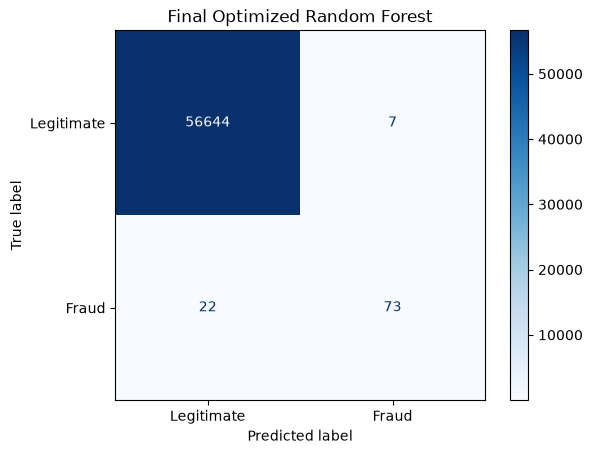

True Positives: 73
True Negatives: 56644
False Positives: 7
False Negatives: 22


In [1]:
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import(train_test_split)
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import(classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, precision_score, recall_score, f1_score)

# Daten laden
RANDOM_STATE = 42
# Datensatz herunterladen
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")
csv_file = Path(path) / "creditcard.csv"
df = pd.read_csv(csv_file)
df = df.drop_duplicates()

# Featrues und Target
X = df.drop("Class", axis=1)
y = df["Class"]
print("Dataset shape:", df.shape)

#Train-Test-Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

# Final Tuned Random Forest
final_rf = RandomForestClassifier(n_estimators=100, max_depth=40, min_samples_split=2, min_samples_leaf=1, 
max_features="log2", class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1)

final_rf.fit(X_train, y_train)

# Probability Predictions
y_prob = final_rf.predict_proba(X_test)[:, 1]

# Optimized Threshold
threshold = 0.3
y_pred = (y_prob >=threshold).astype(int)
print(f"Threshold: {threshold}")

# Evaluation
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1: {f1:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")

# Classification Report
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Legitimate", "Fraud"])
disp.plot(cmap="Blues")
plt.title("Final Optimized Random Forest")
plt.show()

# Error Analysis
tn, fp, fn, tp = cm.ravel()
print(f"True Positives: {tp}")
print(f"True Negatives: {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")

## Key Findings

The final model combines Random Forest hyperparameter optimization with a decision threshold of 0.3.

Compared to the baseline model:

- Precision decreased slightly from 0.9583 to 0.9125
- Recall increased from 0.7263 to 0.7684
- F1-Score improved from 0.8263 to 0.8343
- False Negatives decreased from 26 to 22

The final configuration detected more fraudulent transactions while maintaining a low number of false positive predictions.

The results demonstrate that threshold selection had a greater impact on fraud detection performance than hyperparameter optimization alone.

This highlights the importance of combining technical model optimization with business-oriented decision threshold selection.